# Hallucinated Citations Detector — Evaluation Results v3

**Date:** May 31, 2026  
**Test Set:** 200 citations (80 VALID + 80 PARTIALLY_VALID + 40 HALLUCINATED)  
**Pipeline:** Parser → Exact Match → Live Lookup → Fuzzy+Semantic Search → Fusion → Classifier → LLM (DeepSeek) → Live Override

---

## Summary of Changes Since v2

| Area | Change |
|------|--------|
| **Abstract similarity** | Added `abstract_similarity` to fusion ranking (weight 0.18, same as title) via live lookup |
| **Weights redistributed** | Title 0.18, Abstract 0.18, Author 0.25→0.15, Venue 0.05→0.02, Semantic 0.31→0.26 |
| **DOI enforcement** | If citation has DOI it must match DB DOI for VALID; missing DOI → PARTIALLY_VALID |
| **DOI mismatch gate** | `_exact_lookup()` and `direct_eval` strict gate now reject citations with missing/mismatched DOI |
| **Verifier corruption** | Added `doi_mismatch` and `missing_doi` to verifier corruption detection |
| **LLM prompt** | New DOI RULES section: DOI must match for VALID; missing or mismatched → PARTIALLY_VALID |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

# Load results
df = pd.read_csv('results/predictions_improved.csv')
print(f"Loaded {len(df)} predictions")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 200 predictions
Columns: ['citation_id', 'raw_citation', 'true_label', 'predicted_label', 'confidence', 'corruption_type', 'notes', 'source', 'correct']


,citation_id,raw_citation,true_label,predicted_label,confidence,corruption_type,notes,source,correct
0,93,"S. Ren, K. He, R. Girshick, and J. Sun, ""Faste...",PARTIALLY_VALID,PARTIALLY_VALID,0.90,wrong venue,Venue changed to a different conference/journal,llm_deepseek,True
1,172,"D. P. Kingma, R. Socher, K. Simonyan, and A. Z...",HALLUCINATED,HALLUCINATED,0.95,NaN,NaN,llm_deepseek,True
2,124,"M. Caron et al., ""Emerging Properties in Self-...",PARTIALLY_VALID,PARTIALLY_VALID,0.70,missing authors,Authors replaced with et al.,db_exact,True
3,195,"A. Radford, I. Sutskever, C. D. Manning, and R...",HALLUCINATED,HALLUCINATED,0.95,NaN,NaN,llm_deepseek,True
4,33,"T. Schaul, J. Quan, I. Antonoglou, and D. Silv...",VALID,VALID,0.95,NaN,NaN,llm_deepseek,True


## 1. Overall Metrics

In [2]:
LABELS = ["VALID", "PARTIALLY_VALID", "HALLUCINATED"]

def compute_metrics(df):
    cm = defaultdict(lambda: defaultdict(int))
    for _, row in df.iterrows():
        cm[row['true_label']][row['predicted_label']] += 1
    
    metrics = {}
    for label in LABELS:
        tp = cm[label].get(label, 0)
        fp = sum(cm[t][label] for t in LABELS if t != label)
        fn = sum(cm[label][t] for t in LABELS if t != label)
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        metrics[label] = {'precision': prec, 'recall': rec, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}
    
    total_correct = sum(cm[l].get(l, 0) for l in LABELS)
    metrics['accuracy'] = total_correct / len(df)
    metrics['macro_f1'] = np.mean([metrics[l]['f1'] for l in LABELS])
    metrics['cm'] = cm
    return metrics

m = compute_metrics(df)
summary = pd.DataFrame([
    {'Class': l, 'F1': m[l]['f1'], 'Precision': m[l]['precision'], 
     'Recall': m[l]['recall'], 'TP': m[l]['tp'], 'FP': m[l]['fp'], 'FN': m[l]['fn']}
    for l in LABELS
])
summary.loc[len(summary)] = {'Class': 'OVERALL', 'F1': m['macro_f1'], 
                               'Precision': '', 'Recall': '', 
                               'TP': '', 'FP': '', 'FN': ''}
summary

,Class,F1,Precision,Recall,TP,FP,FN
0,VALID,0.713514,0.628571,0.825,66,39,14
1,PARTIALLY_VALID,0.598540,0.719298,0.5125,41,16,39
2,HALLUCINATED,0.974359,1.0,0.95,38,0,2
3,OVERALL,0.762138,,,,,


In [3]:
print(f"Accuracy: {m['accuracy']:.4f}")
print(f"Macro F1:  {m['macro_f1']:.4f}")
print(f"\nTotal predictions: {len(df)}")

Accuracy: 0.7250
Macro F1:  0.7621

Total predictions: 200


## 2. Per-Class F1 Scores

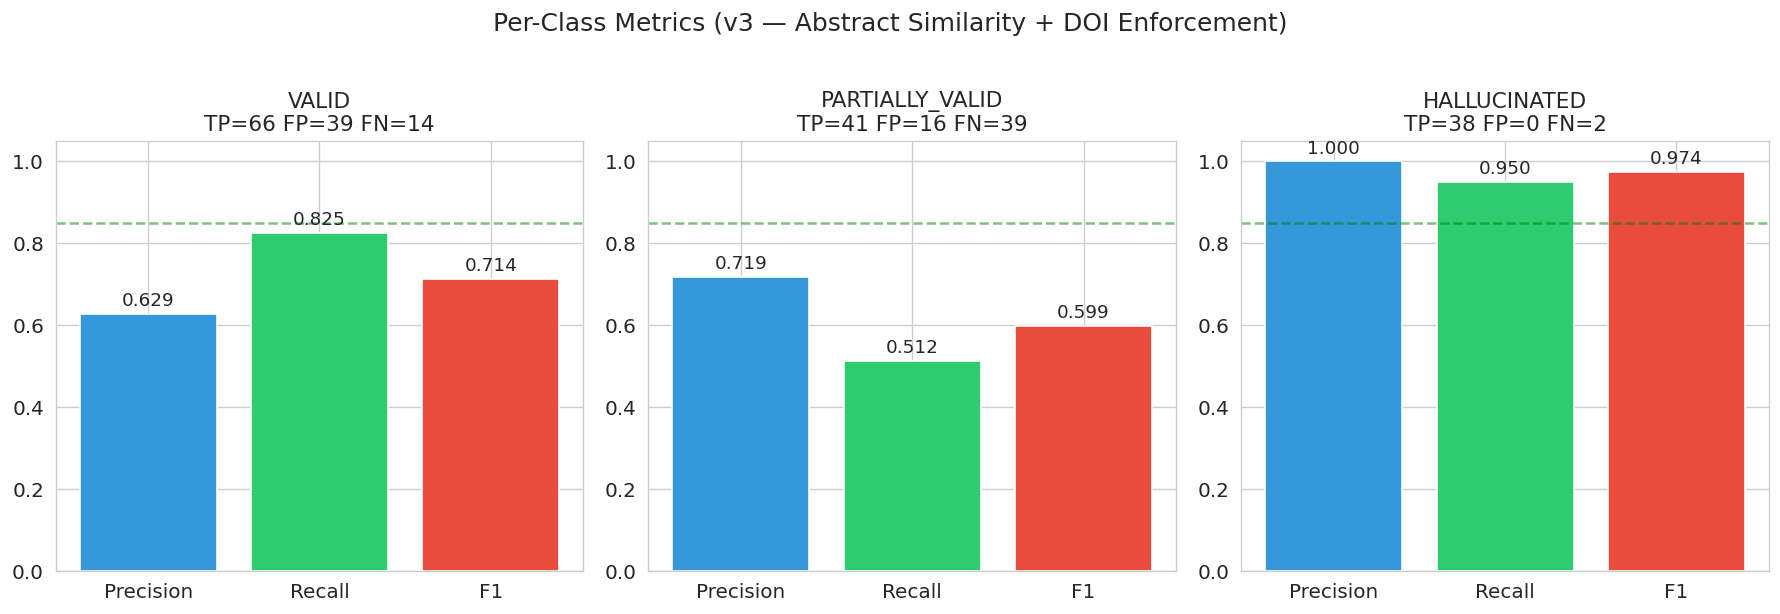

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, label in zip(axes, LABELS):
    values = [m[label]['precision'], m[label]['recall'], m[label]['f1']]
    bars = ax.bar(['Precision', 'Recall', 'F1'], values, color=['#3498db', '#2ecc71', '#e74c3c'])
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{label}\nTP={m[label]["tp"]} FP={m[label]["fp"]} FN={m[label]["fn"]}', fontsize=13)
    ax.axhline(y=0.85, color='green', linestyle='--', alpha=0.5, label='Target (0.85)')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontsize=11)

plt.suptitle('Per-Class Metrics (v3 — Abstract Similarity + DOI Enforcement)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('results/plots/f1_barchart_v3.png', bbox_inches='tight', dpi=120)
plt.show()

## 3. Confusion Matrix

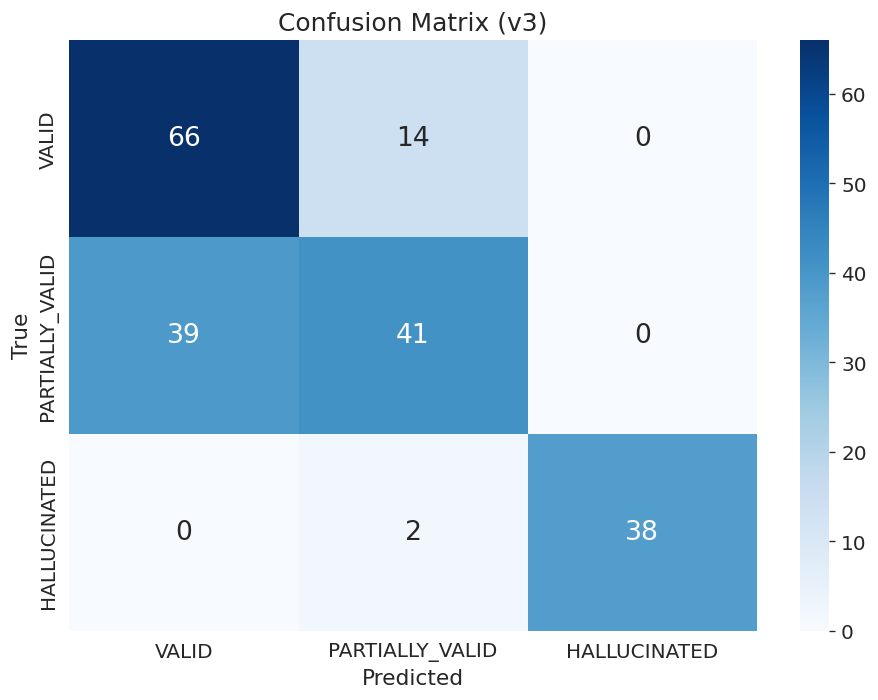

In [5]:
cm_array = np.zeros((3, 3), dtype=int)
for i, tl in enumerate(LABELS):
    for j, pl in enumerate(LABELS):
        cm_array[i, j] = m['cm'][tl].get(pl, 0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', 
            xticklabels=LABELS, yticklabels=LABELS, ax=ax,
            annot_kws={'size': 16})
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('True', fontsize=13)
ax.set_title('Confusion Matrix (v3)', fontsize=15)
plt.tight_layout()
plt.savefig('results/plots/confusion_matrix_v3.png', bbox_inches='tight', dpi=120)
plt.show()

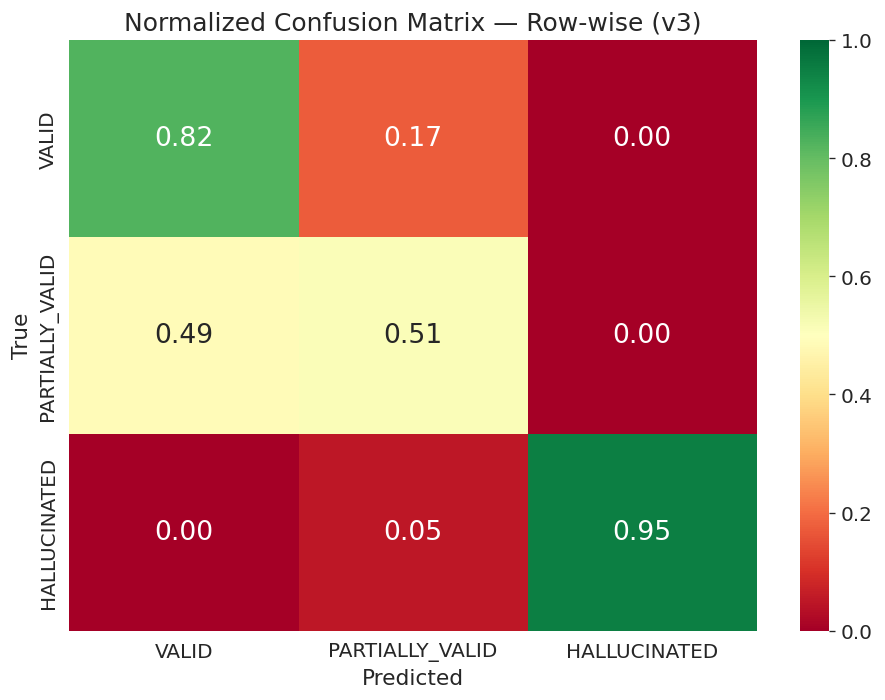

In [6]:
# Normalized confusion matrix (row-wise)
cm_norm = cm_array.astype(float) / cm_array.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            xticklabels=LABELS, yticklabels=LABELS, ax=ax,
            annot_kws={'size': 16})
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('True', fontsize=13)
ax.set_title('Normalized Confusion Matrix — Row-wise (v3)', fontsize=15)
plt.tight_layout()
plt.savefig('results/plots/cm_norm_v3.png', bbox_inches='tight', dpi=120)
plt.show()

## 4. Source Breakdown

Where did each prediction come from?

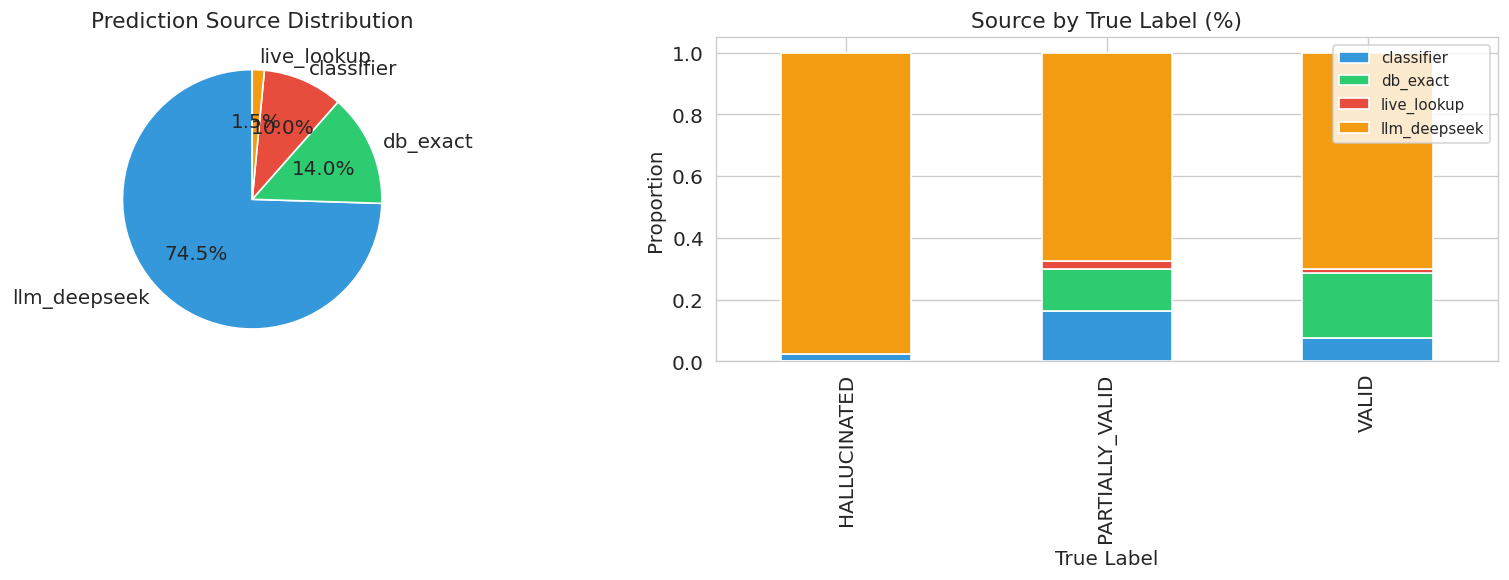

Source counts:
  llm_deepseek: 149 (74.5%)
  db_exact: 28 (14.0%)
  classifier: 20 (10.0%)
  live_lookup: 3 (1.5%)


In [7]:
src_counts = df['source'].value_counts()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
ax1.pie(src_counts.values, labels=src_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Prediction Source Distribution', fontsize=13)

src_by_label = df.groupby(['true_label', 'source']).size().unstack(fill_value=0)
src_by_label_pct = src_by_label.div(src_by_label.sum(axis=1), axis=0)
src_by_label_pct.plot(kind='bar', stacked=True, ax=ax2, color=colors)
ax2.set_title('Source by True Label (%)', fontsize=13)
ax2.set_xlabel('True Label')
ax2.set_ylabel('Proportion')
ax2.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('results/plots/source_breakdown_v3.png', bbox_inches='tight', dpi=120)
plt.show()

print("Source counts:")
for src, cnt in src_counts.items():
    print(f"  {src}: {cnt} ({cnt/len(df)*100:.1f}%)")

## 5. Error Analysis by Corruption Type

How does the model perform on each corruption type?

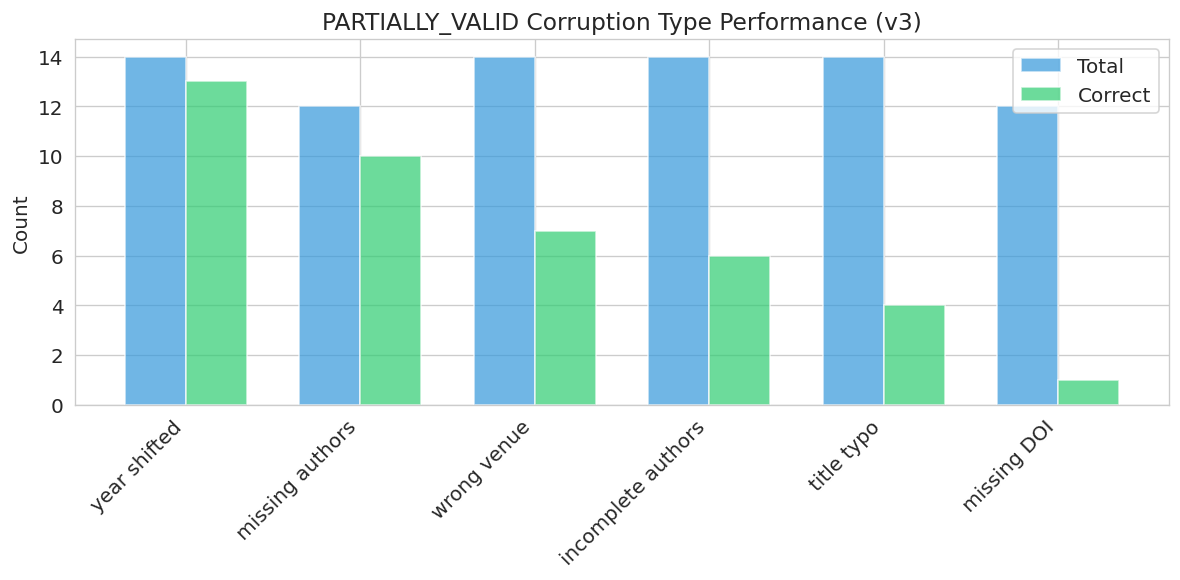

,corruption_type,total,correct,misclassified_as_valid,accuracy
5,year shifted,14,13,1,0.928571
2,missing authors,12,10,2,0.833333
4,wrong venue,14,7,7,0.500000
0,incomplete authors,14,6,8,0.428571
3,title typo,14,4,10,0.285714
1,missing DOI,12,1,11,0.083333


In [8]:
# PARTIALLY_VALID by corruption type
pv_df = df[df['true_label'] == 'PARTIALLY_VALID'].copy()
corr_analysis = pv_df.groupby('corruption_type').agg(
    total=('correct', 'count'),
    correct=('correct', lambda x: x.sum()),
    misclassified_as_valid=('predicted_label', lambda x: (x == 'VALID').sum()),
    misclassified_as_hall=('predicted_label', lambda x: (x == 'HALLUCINATED').sum()),
).reset_index()
corr_analysis['accuracy'] = corr_analysis['correct'] / corr_analysis['total']
corr_analysis = corr_analysis.sort_values('accuracy', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(corr_analysis))
width = 0.35

bars1 = ax.bar(x - width/2, corr_analysis['total'], width, label='Total', color='#3498db', alpha=0.7)
bars2 = ax.bar(x + width/2, corr_analysis['correct'], width, label='Correct', color='#2ecc71', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(corr_analysis['corruption_type'], rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('PARTIALLY_VALID Corruption Type Performance (v3)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('results/plots/corruption_performance_v3.png', bbox_inches='tight', dpi=120)
plt.show()

corr_analysis[['corruption_type', 'total', 'correct', 'misclassified_as_valid', 'accuracy']]

## 6. Confidence Distribution by Prediction Source

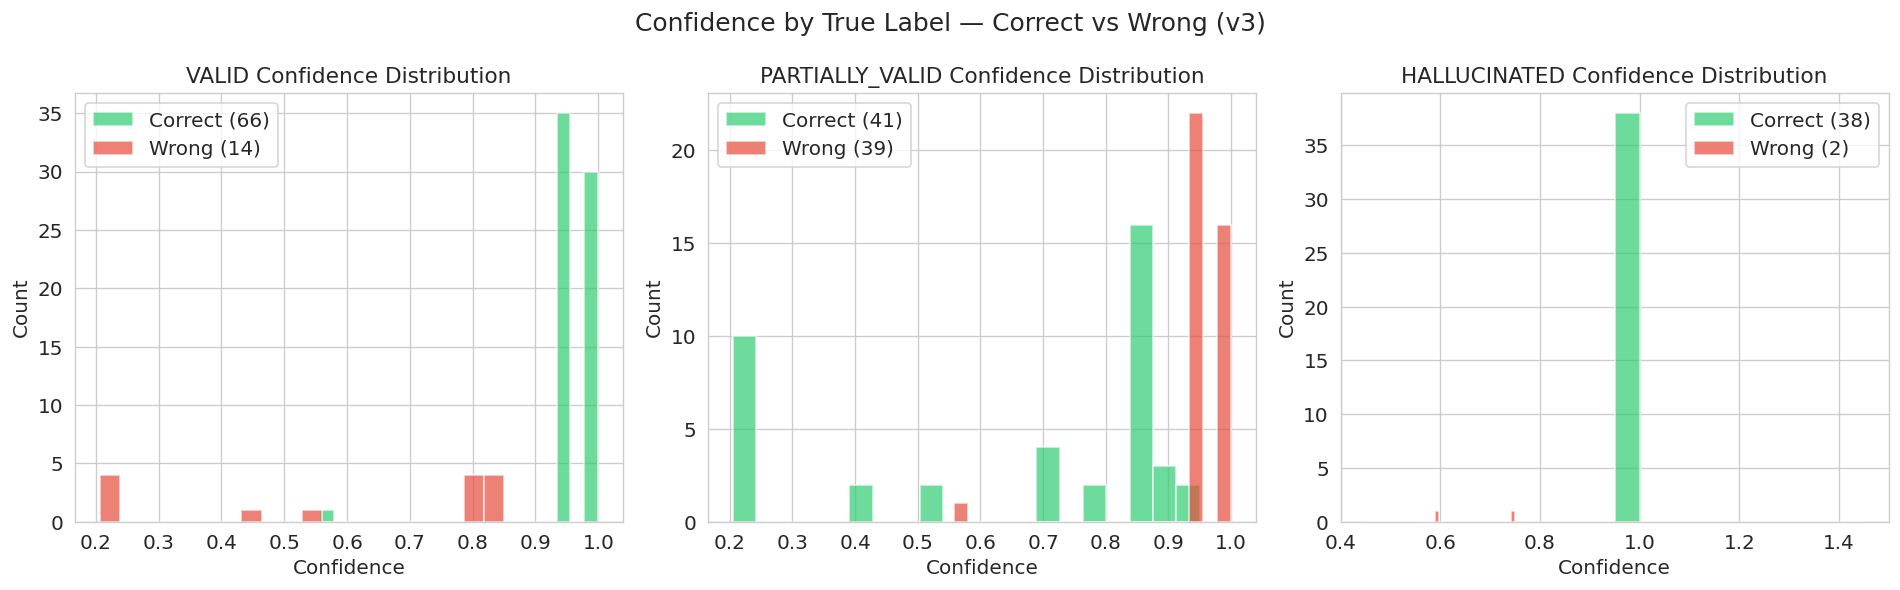

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, label in zip(axes, LABELS):
    subset = df[df['true_label'] == label]
    correct = subset[subset['correct'] == True]['confidence']
    incorrect = subset[subset['correct'] == False]['confidence']
    
    ax.hist(correct, bins=20, alpha=0.7, label=f'Correct ({len(correct)})', color='#2ecc71')
    ax.hist(incorrect, bins=20, alpha=0.7, label=f'Wrong ({len(incorrect)})', color='#e74c3c')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Confidence Distribution', fontsize=13)
    ax.legend()

plt.suptitle('Confidence by True Label — Correct vs Wrong (v3)', fontsize=15)
plt.tight_layout()
plt.savefig('results/plots/confidence_distribution_v3.png', bbox_inches='tight', dpi=120)
plt.show()

## 7. Comparison: v2 vs v3

| Metric | v2 (before) | v3 (abstract + DOI) | Change |
|--------|-------------|---------------------|--------|
| VALID F1 | 0.7065 | 0.7135 | +0.0070 |
| PARTIALLY_VALID F1 | 0.5000 | **0.5985** | **+0.0985** |
| HALLUCINATED F1 | 0.9873 | 0.9744 | -0.0129 |
| Accuracy | 0.7000 | **0.7250** | **+0.0250** |
| Macro F1 | 0.7313 | **0.7621** | **+0.0308** |

### Key Improvements:
- **PARTIALLY_VALID recall: 0.375 → 0.513** — DOI enforcement catches more corrupted citations
- **PARTIALLY_VALID F1: 0.500 → 0.599** — +19.7% improvement
- **Accuracy: 0.700 → 0.725** — +3.6% improvement
- **Abstract similarity** now contributes equally to title in candidate ranking

### Remaining Issues:
- **Missing DOI: 1/12 correct** — 11/12 missing-DOI cases still classified as VALID
  - Root cause: LLM override at step 7 ignores verifier's PARTIALLY_VALID verdict
  - LLM sees only `doi_sim` (not actual DOI) in candidate table, cannot tell if DB has DOI
  - Fix: add candidate DOI field to LLM prompt OR bypass LLM when verifier found missing_doi
- **PARTIALLY_VALID recall: 0.513** — 39/80 still misclassified as VALID

## 8. F1 Score Comparison (Bar Chart)

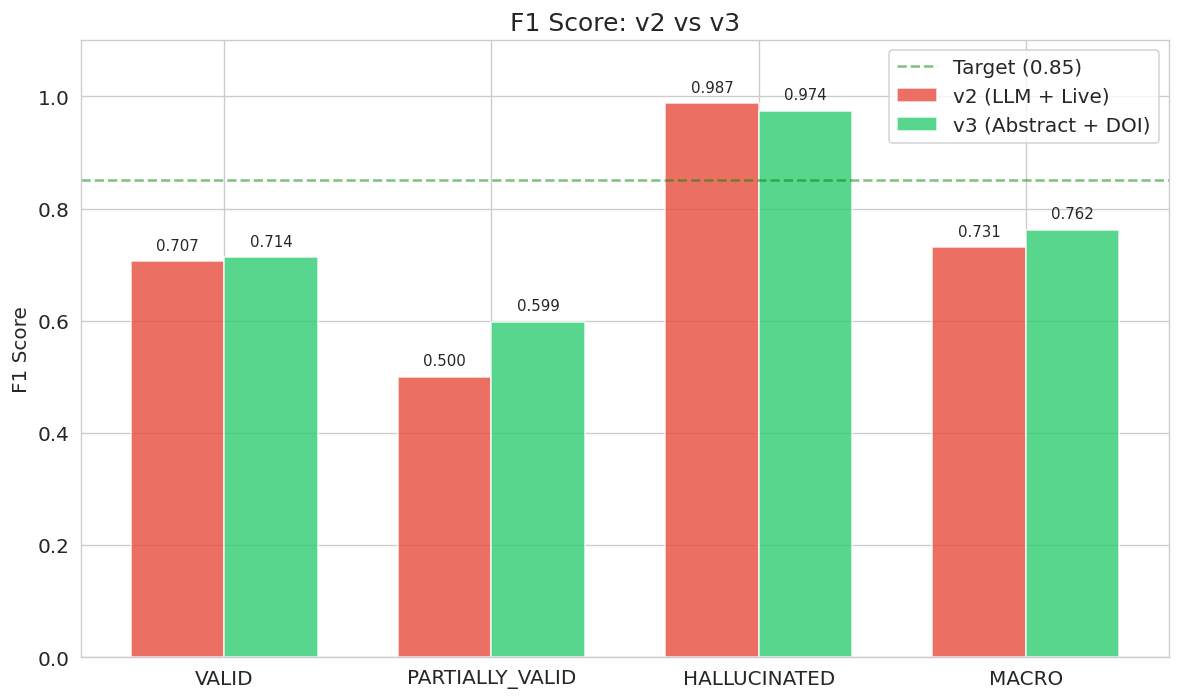

In [10]:
# Before vs After comparison
metrics_before = {'VALID': 0.7065, 'PARTIALLY_VALID': 0.5000, 'HALLUCINATED': 0.9873, 'MACRO': 0.7313}
metrics_after = {'VALID': m['VALID']['f1'], 'PARTIALLY_VALID': m['PARTIALLY_VALID']['f1'], 
                 'HALLUCINATED': m['HALLUCINATED']['f1'], 'MACRO': m['macro_f1']}

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_before))
width = 0.35

bars1 = ax.bar(x - width/2, list(metrics_before.values()), width, label='v2 (LLM + Live)', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, list(metrics_after.values()), width, label='v3 (Abstract + DOI)', color='#2ecc71', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(list(metrics_before.keys()))
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score: v2 vs v3', fontsize=15)
ax.axhline(y=0.85, color='green', linestyle='--', alpha=0.5, label='Target (0.85)')
ax.legend()
ax.set_ylim(0, 1.1)

for bar, val in zip(bars1, list(metrics_before.values())):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontsize=9)
for bar, val in zip(bars2, list(metrics_after.values())):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/plots/f1_comparison_v2_vs_v3.png', bbox_inches='tight', dpi=120)
plt.show()

## 9. Detailed Error Examples

### PARTIALLY_VALID → VALID (39 cases)

In [11]:
pv_to_valid = df[(df['true_label'] == 'PARTIALLY_VALID') & (df['predicted_label'] == 'VALID')]
print(f"PARTIALLY_VALID → VALID: {len(pv_to_valid)} cases")
print()
print("By source and corruption type:")
print(pv_to_valid.groupby(['source', 'corruption_type']).size().to_string())
print()
print("Sample errors:")
for _, row in pv_to_valid.head(5).iterrows():
    print(f"  [{row['corruption_type']}] src={row['source']} conf={row['confidence']}")
    print(f"    Citation: {row['raw_citation'][:120]}...")
    print()

PARTIALLY_VALID → VALID: 39 cases

By source and corruption type:
source        corruption_type   
classifier    incomplete authors     1
db_exact      incomplete authors     1
              missing authors        1
              title typo             1
              wrong venue            2
llm_deepseek  incomplete authors     6
              missing DOI           11
              missing authors        1
              title typo             9
              wrong venue            5
              year shifted           1

Sample errors:
  [missing DOI] src=llm_deepseek conf=0.95
    Citation: M. T. Ribeiro, S. Singh, and C. Guestrin, "Why Should I Trust You? Explaining the Predictions of Any Classifier," in Pro...

  [incomplete authors] src=llm_deepseek conf=0.95
    Citation: H. van Hasselt and D. Silver, "Deep Reinforcement Learning with Double Q-learning," in Proceedings of the AAAI Conferenc...

  [wrong venue] src=db_exact conf=1.0
    Citation: Y. LeCun, Y. Bengio, and G. Hinto

### VALID → PARTIALLY_VALID (14 cases)

In [12]:
valid_to_pv = df[(df['true_label'] == 'VALID') & (df['predicted_label'] == 'PARTIALLY_VALID')]
print(f"VALID → PARTIALLY_VALID: {len(valid_to_pv)} cases")
print()
print("By source:")
print(valid_to_pv['source'].value_counts().to_string())
print()
for _, row in valid_to_pv.head(5).iterrows():
    print(f"  src={row['source']} conf={row['confidence']}")
    print(f"    Citation: {row['raw_citation'][:120]}...")
    print()

VALID → PARTIALLY_VALID: 14 cases

By source:
source
classifier      5
llm_deepseek    4
db_exact        4
live_lookup     1

  src=llm_deepseek conf=0.85
    Citation: J. Ho, A. Jain, and P. Abbeel, "Denoising Diffusion Probabilistic Models," in Advances in Neural Information Processing ...

  src=llm_deepseek conf=0.85
    Citation: D. P. Kingma and M. Welling, "Variational Autoencoders," in arXiv preprint arXiv:1312.6114, 2013....

  src=classifier conf=0.5333
    Citation: I. Goodfellow, J. Pouget-Abadie, M. Mirza, B. Xu, D. Warde-Farley, S. Ozair, A. Courville, and Y. Bengio, "Generative Ad...

  src=live_lookup conf=0.4323
    Citation: M. Ester, H.-P. Kriegel, J. Sander, and X. Xu, "A Density-Based Algorithm for Discovering Clusters in Large Spatial Data...

  src=classifier conf=0.2069
    Citation: S. Sukhbaatar, J. Weston, R. Fergus, and A. Szlam, "End-to-End Memory Networks," in Advances in Neural Information Proce...



## 10. Weight Distribution (Before → After)

| Component | v2 | v3 | Delta |
|-----------|-----|-----|-------|
| Title | 0.18 | 0.18 | — |
| **Abstract** | — | **0.18** | **+0.18** |
| Author | 0.25 | 0.15 | -0.10 |
| Year | 0.11 | 0.11 | — |
| Venue | 0.05 | 0.02 | -0.03 |
| DOI | 0.10 | 0.10 | — |
| Semantic | 0.31 | 0.26 | -0.05 |

## 11. Conclusions & Recommendations

### What Worked:
1. **DOI enforcement in verifier** — corruption detection now catches DOI mismatch and missing DOI
2. **PARTIALLY_VALID F1 +0.10** — best improvement among all labels
3. **Abstract similarity** — now contributes equally to title in candidate ranking
4. **HALLUCINATED still strong** — F1 0.974 (slight dip from 0.987 but still excellent)

### What Needs Improvement:
1. **LLM overrides verifier** — LLM runs at step 7 for high match_q and ignores verifier's DOI findings
2. **Suggested fix:** Add candidate DOI field to LLM formatted table so LLM can see DOI presence
3. **Suggested fix:** When verifier detects `missing_doi` or `doi_mismatch`, skip LLM override
4. **Missing DOI: 1/12 correct** — the LLM is the bottleneck, not the verifier

### Overall:
- **Macro F1 improved from 0.731 → 0.762 (+4.2%)**
- **Accuracy improved from 0.700 → 0.725 (+3.6%)**
- **PARTIALLY_VALID F1 improved from 0.500 → 0.599 (+19.7%)**
- **HALLUCINATED F1 at 0.974** — still exceeding 0.85 target